<a href="https://colab.research.google.com/github/adrienabbet/2025_ML_EES/blob/main/ML_final_project/U_Net_ML_project.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Welcome to my U-Net project to downscale (improve the spatial resolution) Sentinel 3 SLSTR data (1km x 1km spatial resolution) to 30m x 30m using Landsat thermal imagery as our ground truth !

Here, on the left you can visualize the Sentinel Land Surface Temperature image (coarse resolution) and on the right the Landsat 9 TI (Thermal Infrared) image, both are on the exact same spatial extent, over Bern.


(the images shown are geoTIFFs visualized in QGIS, with OSM® as a basemap)


<img src="https://drive.google.com/uc?export=view&id=1a4-Dje-hfpwe3PEfYDO9J7GpPv0FYfqA" width="400">

<img src="https://drive.google.com/uc?export=view&id=1Sd-HVtwCvs1ULvW3gSdSEEX9HJNKvKbo" width="400">







---



# **PART I : LOAD THE DATA**

In [ ]:
#Load those libraries if necessary

#!pip install rasterio
#!pip install pooch
#!pip install cv2

In [1]:
# Satellite data (3 geoTIFF files : Sentinel 3 LST, Landsat 9 LST, and Landsat 9 RGB)

import pooch
data_url = "https://unils-my.sharepoint.com/:u:/g/personal/adrien_abbet_unil_ch/IQBOGN0oTQb_QI2o07SpXpS3AZYQ8lXQJsa16EHh9chODRc?download=1"
hash = '0e632bca8b3df129d8cce01d9dc0ea6fc7fa39af7c7e5ac1bd7d3f1f7379fdb2'
data = pooch.retrieve(data_url, known_hash=hash, processor=pooch.Unzip())

Unzipping contents of '/root/.cache/pooch/6c31bade4c08fbc120b0354d6e6095ae-IQBOGN0oTQb_QI2o07SpXpS3AZYQ8lXQJsa16EHh9chODRc' to '/root/.cache/pooch/6c31bade4c08fbc120b0354d6e6095ae-IQBOGN0oTQb_QI2o07SpXpS3AZYQ8lXQJsa16EHh9chODRc.unzip'


In [2]:
print(data)

['/root/.cache/pooch/6c31bade4c08fbc120b0354d6e6095ae-IQBOGN0oTQb_QI2o07SpXpS3AZYQ8lXQJsa16EHh9chODRc.unzip/SEN3_LST_25082022.tif', '/root/.cache/pooch/6c31bade4c08fbc120b0354d6e6095ae-IQBOGN0oTQb_QI2o07SpXpS3AZYQ8lXQJsa16EHh9chODRc.unzip/LS9_LST_25082022.tif', '/root/.cache/pooch/6c31bade4c08fbc120b0354d6e6095ae-IQBOGN0oTQb_QI2o07SpXpS3AZYQ8lXQJsa16EHh9chODRc.unzip/true_image_ls9.tif', '/root/.cache/pooch/6c31bade4c08fbc120b0354d6e6095ae-IQBOGN0oTQb_QI2o07SpXpS3AZYQ8lXQJsa16EHh9chODRc.unzip/__MACOSX/._true_image_ls9.tif', '/root/.cache/pooch/6c31bade4c08fbc120b0354d6e6095ae-IQBOGN0oTQb_QI2o07SpXpS3AZYQ8lXQJsa16EHh9chODRc.unzip/__MACOSX/._LS9_LST_25082022.tif', '/root/.cache/pooch/6c31bade4c08fbc120b0354d6e6095ae-IQBOGN0oTQb_QI2o07SpXpS3AZYQ8lXQJsa16EHh9chODRc.unzip/__MACOSX/._SEN3_LST_25082022.tif']


Now, let's load the satellite thermal and RGB data using rasterio :

In [3]:
#load the data
import rasterio

sen3_path = [p for p in data if "SEN3_LST_25082022" in p][0]
ls9_path  = [p for p in data if "LS9_LST_25082022" in p][0]
rgb_path  = [p for p in data if "true_image_ls9" in p][0]


with rasterio.open(sen3_path) as src_sen3_25082022:
    sen3_25082022 = src_sen3_25082022.read(1)
    print("Shape :", sen3_25082022.shape)

with rasterio.open(ls9_path) as src_ls9_25082022:
    ls9_25082022 = src_ls9_25082022.read(1)
    print("Shape :", ls9_25082022.shape)

with rasterio.open(rgb_path) as src_true_image:
    blue  = src_true_image.read(3)    #blue channel
    green = src_true_image.read(4)   #green
    red   = src_true_image.read(5)    #and red
    print(src_true_image.count)

Shape : (38, 38)
Shape : (1256, 1273)
5


# **PART II : PREPROCESSING**

Here, i set the Sentinel image resolution to landsat's one as target, so the arrays have compatible sizes in the CNN later.

For example, if a sentinel pixel is 1km by 1km and has a temperature value of 23°C, then it will be subdivided in smaller pixels, all with also a temperature of 23°C

In [4]:
# reshape of the sentinel temperature matrix into ls9's using a nearest neighbour interpolation for pixels at the edge.

import cv2 as cv
import numpy as np

target_shape = ls9_25082022.shape  # get the dimensions of target

sen3_resized = cv.resize(
    sen3_25082022,
    (target_shape[1], target_shape[0]),   # CV uses (width, height), so we need to invert the tuple
    interpolation=cv.INTER_NEAREST
)
print(f'Sentinel 3 image has diimensions {sen3_resized.shape} after reshape',
      ' ', sep='\n')

X = np.stack([sen3_resized, red, green, blue], axis=-1)  #stack raw temperature and rgb matrices together
y = ls9_25082022 # our y data

print("Shapes :")  #sizes verification
print("Sen3 (resized) :", sen3_resized.shape)
print("ls9 Red       :", red.shape)
print("ls9 Green     :", green.shape)
print("ls9 Blue      :", blue.shape)
print("ls9 LST       :", ls9_25082022.shape)

Sentinel 3 image has diimensions (1256, 1273) after reshape
 
Shapes :
Sen3 (resized) : (1256, 1273)
ls9 Red       : (1256, 1273)
ls9 Green     : (1256, 1273)
ls9 Blue      : (1256, 1273)
ls9 LST       : (1256, 1273)



Then, we create a function to create the data patches for the model

In [5]:
# Fonction to create patches and their coordinates (mandatory for U-Nets)
def patches_with_coords(img, patch_size=128, stride=64):  #values for patch_size and stride if not specified
    patches = []
    coords = []
    H, W = img.shape[:2]

    for i in range(0, H - patch_size + 1, stride):
        for j in range(0, W - patch_size + 1, stride):
            patch = img[i:i+patch_size, j:j+patch_size]
            patches.append(patch)
            coords.append((i, j))
    return np.array(patches), coords

In [6]:
patch_size = 128
stride = 64

# we apply the function with a stride of 64, so 50% overlab between patches (i chose 50% of overlap because my dataset is not very large)
# we obtain the patches (sub-divisions of the image) and the coordinates ('the position of the patch in the original image, necessary to reconstruct an image at the end)
X_patches, X_coords = patches_with_coords(X, patch_size, stride)
y_patches, y_coords = patches_with_coords(y, patch_size, stride)

X_patches = np.transpose(X_patches, (0, 3, 1, 2))
y_patches = y_patches[:, None, :, :]

print(X_patches.shape, y_patches.shape) #always a good idea to check dimensions

#-----------------------------------------------------
#one should obtain something like : (n_patchs, n_channels, height, width)

(324, 4, 128, 128) (324, 1, 128, 128)



After that, we split ou dataset into train/val/test, carefully avoiding spatial autocorrelation.

In [7]:
#Now, since the strides overlap by 50% (because stride of 64 with a patch_size of 128), a random train/test split would not work (spatial autocorr)
# so let's do better : let's split by lines of patches (spatial split)
rows = sorted(set(i for i, j in X_coords))
cols = sorted(set(j for i, j in X_coords))
n_h = len(rows)  #number of rows in the patchs
n_w = len(cols)  #number oof columns

print("Number of rows :", n_h)   #to verify
print("Number of columns :", n_w)  #same
print(' ')

# Split of the dataset
train_rows = rows[:12] #12
val_rows   = rows[12:15] #3
test_rows  = rows[15:18] #3

#fonction to select the needed patches
def select_by_rows(patches, coords, selected_rows):
    return np.array([p for p, (i, j) in zip(patches, coords) if i in selected_rows])

#execution to finally get a train/val/test split
X_train = select_by_rows(X_patches, X_coords, train_rows)
y_train = select_by_rows(y_patches, y_coords, train_rows)

X_val = select_by_rows(X_patches, X_coords, val_rows)
y_val = select_by_rows(y_patches, y_coords, val_rows)

X_test = select_by_rows(X_patches, X_coords, test_rows)
y_test = select_by_rows(y_patches, y_coords, test_rows)

#siize verification
print("Train shape :", X_train.shape) #66.6%
print("Val shape  :", X_val.shape)   #16.67%
print("Test shape :", X_test.shape)  #16.67%
print(' ')

percentage_train = X_train.shape[0] / (X_train.shape[0] + X_val.shape[0] + X_test.shape[0])*100
percentage_val = X_val.shape[0] / (X_train.shape[0] + X_val.shape[0] + X_test.shape[0])*100
percentage_test = X_test.shape[0] /(X_train.shape[0] + X_val.shape[0] + X_test.shape[0])*100
print(f'Train set takes {percentage_train:.1f}% of the total dataset',
        f'Validation set takes {percentage_val:.1f}% of the total dataset',
        f'Test set takes {percentage_test:.1f}% of the total dataset', sep='\n')

Number of rows : 18
Number of columns : 18
 
Train shape : (216, 4, 128, 128)
Val shape  : (54, 4, 128, 128)
Test shape : (54, 4, 128, 128)
 
Train set takes 66.7% of the total dataset
Validation set takes 16.7% of the total dataset
Test set takes 16.7% of the total dataset


Here we are, our dataset is sucessfully split. We will now modify it in torch-accepted format !

In [8]:
#next part: train/val/test split but for torch
import torch
from torch.utils.data import TensorDataset, DataLoader

#conversion numpy en torch
X_train = torch.tensor(X_train, dtype=torch.float32)
y_train = torch.tensor(y_train, dtype=torch.float32)

X_val = torch.tensor(X_val, dtype=torch.float32)
y_val = torch.tensor(y_val, dtype=torch.float32)

X_test = torch.tensor(X_test, dtype=torch.float32)
y_test = torch.tensor(y_test, dtype=torch.float32)

#datasets (regroups sample with its ground truth)
train_ds = TensorDataset(X_train, y_train)
val_ds = TensorDataset(X_val, y_val)
test_ds = TensorDataset(X_test, y_test)

#dataloaders (to apply batchs to the dataset)
train_dl = DataLoader(train_ds, batch_size=16, shuffle=True, num_workers=0)
val_dl = DataLoader(val_ds, batch_size=16)
test_dl = DataLoader(test_ds, batch_size=16)
print("DataLoaders ready !")

DataLoaders ready !


This is now a format recognized by torch, let's get on with the U-Net architecture !



---



# **PART III : MODEL ARCHITECTURE**

U-Net architecture example (note : it is not the same as in this project, but just to give an idea of wh it's called "U-Net")

<img src="https://drive.google.com/uc?export=view&id=1AmSVNtXkOusOpl990GLJQjTGDfG7Yxlk" width="800">

image source : https://en.wikipedia.org/wiki/U-Net#/media/File:Example_architecture_of_U-Net_for_producing_k_256-by-256_image_masks_for_a_256-by-256_RGB_image.png


In [9]:
# U-Net definition
import torch.nn as nn

class DoubleConv(nn.Module): #DoubleConv creates 2 conv layers consecutively (both with a ReLU activation here)
    def __init__(self, in_channels, out_channels):
        super().__init__()
        self.conv = nn.Sequential(
            nn.Conv2d(in_channels, out_channels, kernel_size=3, padding=1),
            nn.ReLU(inplace=True),
            nn.Conv2d(out_channels, out_channels, kernel_size=3, padding=1),
            nn.ReLU(inplace=True)
        )

    def forward(self, x):
        return self.conv(x)

class UNet(nn.Module):
    def __init__(self):
        super().__init__()

        # ENCODER (extracts more and more abstract features)
        self.down1 = DoubleConv(4, 64)
        self.pool1 = nn.MaxPool2d(2)

        self.down2 = DoubleConv(64, 128)
        self.pool2 = nn.MaxPool2d(2)

        self.down3 = DoubleConv(128, 256)
        self.pool3 = nn.MaxPool2d(2)

        # Bottleneck with Dropout
        self.bottleneck = nn.Sequential(
            nn.Conv2d(256, 512, kernel_size=3, padding=1),
            nn.ReLU(inplace=True),
            nn.Conv2d(512, 512, kernel_size=3, padding=1),
            nn.ReLU(inplace=True),
            nn.Dropout(0.2)
        )

        # DECODER (recombines the discovered features in the encoder)
        self.up3 = nn.ConvTranspose2d(512, 256, kernel_size=2, stride=2)
        self.conv3 = DoubleConv(512, 256)

        self.up2 = nn.ConvTranspose2d(256, 128, kernel_size=2, stride=2)
        self.conv2 = DoubleConv(256, 128)

        self.up1 = nn.ConvTranspose2d(128, 64, kernel_size=2, stride=2)
        self.conv1 = DoubleConv(128, 64)

        # Output layer (1 channel because LST is single-band for our output)
        self.out_conv = nn.Conv2d(64, 1, kernel_size=1)

    def forward(self, x):
        # Encoder
        x1 = self.down1(x)
        x2 = self.down2(self.pool1(x1))
        x3 = self.down3(self.pool2(x2))

        # Bottleneck
        x4 = self.bottleneck(self.pool3(x3))

        # Decoder
        x = self.up3(x4)
        x = self.conv3(torch.cat([x, x3], dim=1))

        x = self.up2(x)
        x = self.conv2(torch.cat([x, x2], dim=1))

        x = self.up1(x)
        x = self.conv1(torch.cat([x, x1], dim=1))

        return self.out_conv(x)

We can instanciate the U-Net model :

In [10]:
#Just to verif we're running on the colab GPU
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Running on", device)


Running on cpu


In [11]:
model = UNet().to(device)  # Instanciation

Initialization of the chosen loss functions (here mse & mae) and the optimizer (adam)

In [12]:
mse = nn.MSELoss() #MSE
mae = nn.L1Loss()  #MAE

# optimizer
optimizer = torch.optim.Adam(model.parameters(), lr=1e-4)

Let's implement a NSE (Nash-Sutcliffe efficiency) index, not as a loss, but as additional information fro our understanding of the model !

In [13]:
import torch

def nse(pred, target, eps=1e-8):
    """
    Compute nse for batches of images.

    pred, target : tensors of shape (B, 1, H, W)
    """
    # Flatten all spatial dims per batch
    pred_f = pred.view(pred.size(0), -1)
    target_f = target.view(target.size(0), -1)
    # Mean of observations per batch
    target_mean = torch.mean(target_f, dim=1, keepdim=True)
    # Numerator and denominator
    num = torch.sum((target_f - pred_f) ** 2, dim=1)
    den = torch.sum((target_f - target_mean) ** 2, dim=1) + eps
    nse_batch = 1 - (num/den)
    return nse_batch.mean()

# **PART IV : TRAINING**

We're finall gonna trian the model on our data ! let's not wait any more ! (better on the colab gpu)

In [ ]:
best_val_mse = float("inf")
best_epoch = -1

num_epochs = 20

# instantiation of empt lists to store the loss values at each epoch in order to plot the graphs later on
train_mse_history = []
train_mae_history = []
val_mse_history = []
val_mae_history = []
train_nse_history = []
val_nse_history = []


import time
t_start = time.time()
print('starting training...')
for epoch in range(num_epochs):

    #let's train
    model.train()
    train_mse = 0
    train_mae = 0
    train_nse = 0

    for xb, yb in train_dl:
        xb = xb.to(device)
        yb = yb.to(device)

        optimizer.zero_grad()

        pred = model(xb)

        loss = mse(pred, yb)
        loss.backward()
        optimizer.step()

        train_mse += loss.item()
        train_mae += mae(pred, yb).item()
        train_nse += nse(pred, yb).item()

    #and validate
    model.eval()
    val_mse = 0
    val_mae = 0
    val_nse = 0

    with torch.no_grad():
        for xb, yb in val_dl:
            xb = xb.to(device)
            yb = yb.to(device)

            pred = model(xb)

            val_mse += mse(pred, yb).item()
            val_mae += mae(pred, yb).item()
            val_nse += nse(pred, yb).item()
            avg_val_mse = val_mse / len(val_dl)

    if avg_val_mse < best_val_mse:  #to check and save to model weight at the best epoch !
        best_val_mse = avg_val_mse
        best_epoch = epoch + 1
        torch.save(model.state_dict(), "best_unet_weights.pth")
        print(f" --> Best model saved (epoch {epoch+1}, Val MSE = {avg_val_mse:.2f})")

    print(
        f"Epoch {epoch+1}/{num_epochs} | "
        f"Train MSE: {train_mse/len(train_dl):.2f} | "
        f"Train MAE: {train_mae/len(train_dl):.2f} | "
        f"Val MSE: {val_mse/len(val_dl):.2f} | "
        f"Val MAE: {val_mae/len(val_dl):.2f}"
    )

    train_mse_history.append(train_mse / len(train_dl)) # adds at each epoch the corresponding loss values (& SSIM)
    train_mae_history.append(train_mae / len(train_dl))
    val_mse_history.append(val_mse / len(val_dl))
    val_mae_history.append(val_mae / len(val_dl))
    train_nse_history.append(train_nse / len(train_dl))
    val_nse_history.append(val_nse / len(val_dl))

t_final = time.time()
print(f'training took {t_final-t_start:.1f} seconds')

starting training...
 --> Best model saved (epoch 1, Val MAE = 12.18)
Epoch 1/20 | Train MSE: 646.23 | Train MAE: 20.19 | Val MSE: 171.22 | Val MAE: 12.18
 --> Best model saved (epoch 2, Val MAE = 7.46)
Epoch 2/20 | Train MSE: 93.88 | Train MAE: 7.91 | Val MSE: 70.20 | Val MAE: 7.46
 --> Best model saved (epoch 3, Val MAE = 4.30)
Epoch 3/20 | Train MSE: 35.53 | Train MAE: 4.68 | Val MSE: 27.48 | Val MAE: 4.30
 --> Best model saved (epoch 4, Val MAE = 2.67)
Epoch 4/20 | Train MSE: 19.04 | Train MAE: 3.29 | Val MSE: 12.97 | Val MAE: 2.67
 --> Best model saved (epoch 5, Val MAE = 2.52)
Epoch 5/20 | Train MSE: 12.71 | Train MAE: 2.61 | Val MSE: 11.23 | Val MAE: 2.52
 --> Best model saved (epoch 6, Val MAE = 2.24)
Epoch 6/20 | Train MSE: 9.18 | Train MAE: 2.22 | Val MSE: 8.65 | Val MAE: 2.24
 --> Best model saved (epoch 7, Val MAE = 1.87)
Epoch 7/20 | Train MSE: 7.68 | Train MAE: 2.03 | Val MSE: 6.35 | Val MAE: 1.87
 --> Best model saved (epoch 8, Val MAE = 1.73)
Epoch 8/20 | Train MSE: 6.5

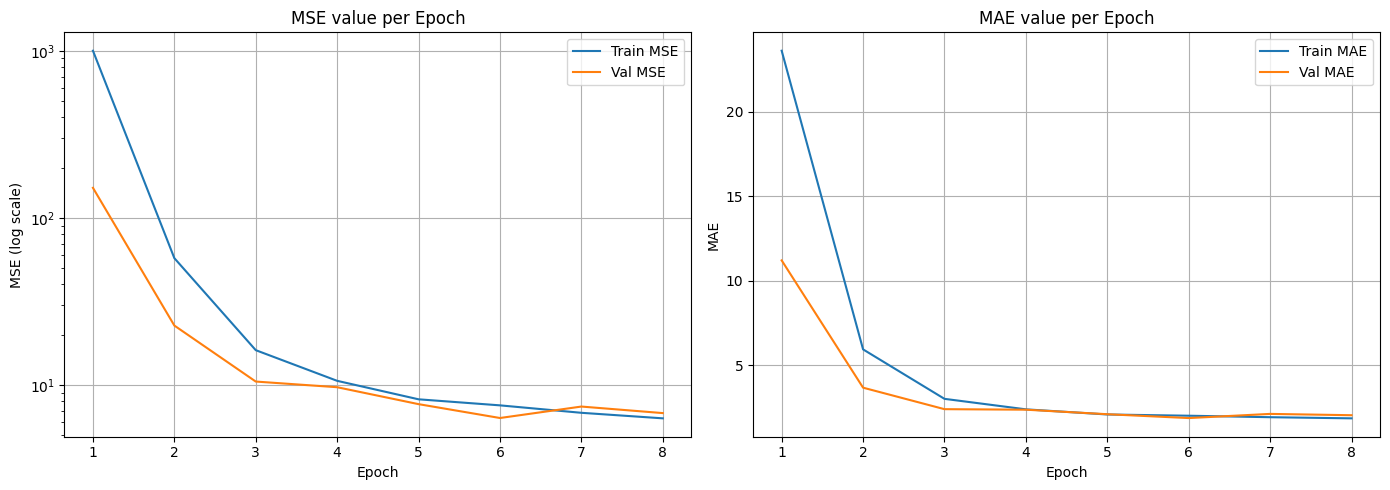

In [ ]:
# loss graphs plotting
import matplotlib.pyplot as plt

epochs = np.arange(1, num_epochs + 1)

plt.figure(figsize=(14, 5))

# MSE
plt.subplot(1, 2, 1)
plt.plot(epochs, train_mse_history, label="Train MSE")
plt.plot(epochs, val_mse_history, label="Val MSE")
plt.yscale("log")
plt.title("MSE value per Epoch")
plt.xlabel("Epoch")
plt.ylabel("MSE (log scale)")
plt.grid(True)
plt.legend()

# MAE
plt.subplot(1, 2, 2)
plt.plot(epochs, train_mae_history, label="Train MAE")
plt.plot(epochs, val_mae_history, label="Val MAE")
#plt.yscale("log") #if necessary
plt.title("MAE value per Epoch")
plt.xlabel("Epoch")
plt.ylabel("MAE")
plt.grid(True)
plt.legend()

plt.tight_layout()
plt.show()


# **PART V : TEST**

In [ ]:
#Let's load the best weights to test the model
best_model = UNet()
best_model.load_state_dict(torch.load("best_unet_weights.pth"))
best_model.eval()

test_mse = 0  # on instancie les test losses à zero
test_mae = 0
test_nse = 0  # et aussi la nse

with torch.no_grad():
    for xb, yb in test_dl:
        pred = best_model(xb)

        test_mse += mse(pred, yb).item()
        test_mae += mae(pred, yb).item()
        test_nse += nse(pred, yb).item()

test_mse /= len(test_dl)
test_mae /= len(test_dl)
test_nse /= len(test_dl)

print(f"Test MSE: {test_mse:.2f}")
print(f"Test MAE: {test_mae:.2f}")
print(f'Test nse: {test_nse:.2f}')


Test MSE: 6.13
Test MAE: 1.87
Test nse: -0.24


# PART VI : RECONSTRUCTING THE TEST IMAGE

In [ ]:
#code pour recontruire l'image landsat a partir des y_pred générés par le U-Net

#iimage reconstruction
#load best model
best_model = UNet()
best_model.load_state_dict(torch.load("best_unet_weights.pth"))
best_model.eval()

#predict all patches
all_preds = []
with torch.no_grad():
    for xb, _ in test_dl:
        pred = best_model(xb)
        all_preds.append(pred.numpy())

all_preds = np.concatenate(all_preds, axis=0)  # shape (N, 1, 128, 128)
print("Pred patches:", all_preds.shape)

#extraire uniquement les coordonnées des patches du test
test_coords = [(i, j) for (i, j) in y_coords if i in test_rows]

print("Nb coords test :", len(test_coords))      # doit = all_preds.shape[0]

H, W = y.shape  # dimensions de l'image finale Landsat
reconstructed = np.zeros((H, W), dtype=np.float32)
count = np.zeros((H, W), dtype=np.float32)

#reconstruction seulement sur les patches de test
for patch_idx, (i, j) in enumerate(test_coords):

    pred_patch = all_preds[patch_idx, 0]   # enlever dimension channel (1,128,128)

    reconstructed[i:i+patch_size, j:j+patch_size] += pred_patch
    count[i:i+patch_size, j:j+patch_size] += 1

# Moyenne dans les zones recouvertes
reconstructed /= count

print("Reconstructed image shape:", reconstructed.shape)


Pred patches: (54, 1, 128, 128)
Nb coords test : 54
Reconstructed image shape: (1256, 1273)


/tmp/ipython-input-1211649245.py:37: RuntimeWarning: invalid value encountered in divide
  reconstructed /= count


**Let's see it :**

<Figure size 1800x600 with 0 Axes>

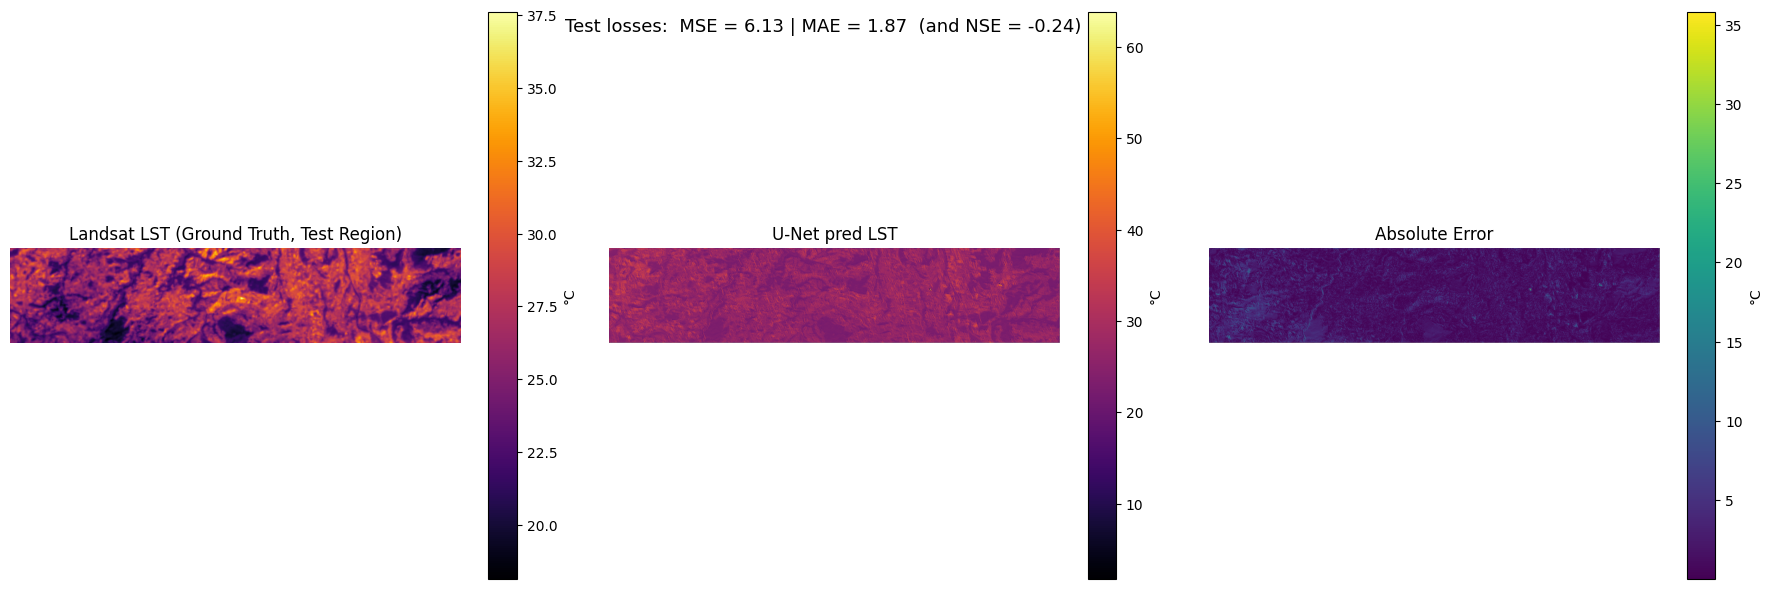

In [ ]:
#affichage de l'image reconstruite + heatmap des valeurs absolues !
import matplotlib.pyplot as plt
import numpy as np

# Compute bounding box of test region
min_i = min(i for i, j in test_coords)
max_i = max(i for i, j in test_coords) + patch_size
min_j = min(j for i, j in test_coords)
max_j = max(j for i, j in test_coords) + patch_size

# Crop ground truth to same region as reconstructed
y_test_region = y[min_i:max_i, min_j:max_j]

#calcul de la heatmap
error_map = np.abs(reconstructed - y)

plt.figure(figsize=(18, 6))
fig = plt.figure(figsize=(18, 6))

#this is to add the loss/metrics value in the plot
fig.text(
    0.46, 0.96,
    f"Test losses:  MSE = {test_mse:.2f} | MAE = {test_mae:.2f}  (and NSE = {test_nse:.2f})",
    ha="center", va="top",
    fontsize=13, color="black",
    bbox=dict(facecolor="white", alpha=0.6, edgecolor="none")
)


# Ground truth (landsat 9 LST)
plt.subplot(1, 3, 1)
plt.title("Landsat LST (Ground Truth, Test Region)")
plt.axis("off")
plt.imshow(y_test_region, cmap="inferno", aspect="equal")
plt.colorbar(label="°C")

# Predicted region
plt.subplot(1, 3, 2)
plt.title("U-Net pred LST")
plt.axis("off")
plt.imshow(reconstructed, cmap="inferno", aspect="equal")
plt.colorbar(label="°C")
plt.xlim(min_j, max_j)
plt.ylim(max_i, min_i)

# Error heatmap
plt.subplot(1, 3, 3)
plt.title("Absolute Error")
plt.axis("off")
plt.imshow(error_map, cmap="viridis", aspect="equal")
plt.colorbar(label="°C")
plt.xlim(min_j, max_j)
plt.ylim(max_i, min_i)

plt.tight_layout()
plt.show()


# And VOILA ! :)
